In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [3]:
path = '/content/drive/MyDrive/Colab Notebooks/wine.csv'
df = pd.read_csv(path)

In [5]:
y=df['Wine']
X=df.drop('Wine',axis=1)

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

Y = pd.get_dummies(y).values #one-hot

X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0, stratify=y)

In [7]:
model = models.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(Y.shape[1], activation="softmax")
])


model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3894 - loss: 1.0826 - val_accuracy: 0.4828 - val_loss: 0.9887
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6018 - loss: 0.9248 - val_accuracy: 0.6897 - val_loss: 0.8448
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7699 - loss: 0.7911 - val_accuracy: 0.7586 - val_loss: 0.7199
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8407 - loss: 0.6687 - val_accuracy: 0.8621 - val_loss: 0.6091
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9381 - loss: 0.5847 - val_accuracy: 0.9310 - val_loss: 0.4996
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9558 - loss: 0.4711 - val_accuracy: 0.9310 - val_loss: 0.4060
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9646 - loss: 0.3753 - val_accuracy: 0.9310 - val_loss: 0.3300
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9469 - loss: 0.3194 - val_accuracy: 0.9310 - val_loss: 0.2683


In [9]:
y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

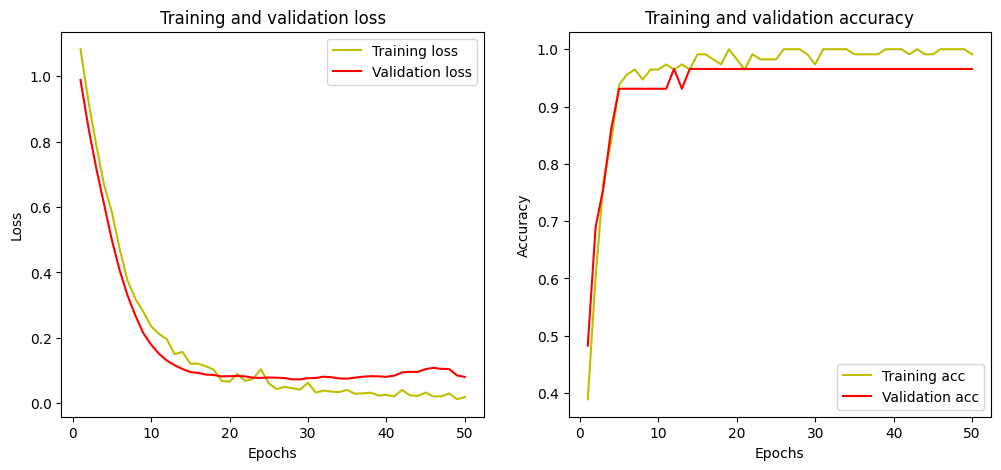

In [12]:
# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [13]:
#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
